In [1]:
import pandas as pd
import torch
import torchaudio
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

beats_path = r"C:\Users\Lindholm\Documents\BSc\unilm\beats"
sys.path.append(beats_path)
from BEATs import BEATs, BEATsConfig

In [2]:
def load_beats_model(ckpt_path: Path, device: torch.device):
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    cfg = BEATsConfig(checkpoint["cfg"])
    model = BEATs(cfg)
    model.load_state_dict(checkpoint["model"])
    model.to(device)
    model.eval()
    return model

In [3]:
def load_audio(path, target_sr=16000): # BEATs expects 16 kHz audio.
    wav, sr = torchaudio.load(path)
    if wav.shape[0] > 1:
        wav = torch.mean(wav, dim=0, keepdim=True)
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
        sr = target_sr
    return wav, sr 

@torch.no_grad()
def extract_beats_feats(model, wav: torch.Tensor, device: torch.device):
    wav = wav.to(device)
    x, padding_mask = model.extract_features(wav, padding_mask=None)
    # BEATs automatically calls self.preprocess to normalize the mel filterbanks.
    return x, padding_mask

In [4]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

# AudioSet labels.
df_labels = pd.read_csv(r"D:\AudioSet labels\class_labels_indices.csv")
df_labels = df_labels.set_index("index")
labels = df_labels["display_name"].to_list()

val1_path = Path(r"D:\data_dryad\Tracy_6230\6230.220917120000.wav")
val2_path = Path(r"D:\data_dryad\Tracy_6230\6230.221003000000.wav")

ckpt_path = Path(r"D:\beats_model_weights\BEATs_iter3_plus_AS2M.pt")
# Returns embedding vectors: B, T_frames, C_dim.
# ckpt_path = Path(r"D:\beats_model_weights\BEATs_iter3_plus_AS2M_finetuned_on_AS2M_cpt1.pt")
# Returns tag probabilities for 527 classes: B, L.

audio_path = val1_path

model = load_beats_model(ckpt_path, device)
wav, sr = load_audio(audio_path, target_sr=16000)
print(wav.shape)

t_start, t_end = 25.0, 35.0
start = int(t_start * sr)
end = int(t_end * sr)
wav_clip = wav[:, start:end]
print(f".wav clip shape = {wav_clip.shape}")

x, padding_mask = extract_beats_feats(model, wav_clip, device)

# Shapes.
if x.ndim == 3:
    B, T_frames, C_dim = x.shape
    print("Frame-level:", B, T_frames, C_dim)
elif x.ndim == 2:
    B, C_dim = x.shape
    print(f"Clip-level pooled:, {B}, {C_dim}")

C:\Users\Lindholm\AppData\Local\Temp\ipykernel_22004\3831267905.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location="cpu")
c:

torch.Size([1, 4319004])
.wav clip shape = torch.Size([1, 160000])
Frame-level: 1 496 768


In [5]:
# topk = 15
# vals, idx = torch.topk(x[0], k=topk)
# for i, v in zip(idx.tolist(), vals.tolist()):
#     print(i, labels[i], v)
# # print(torch.stack([idx, vals], dim=1))

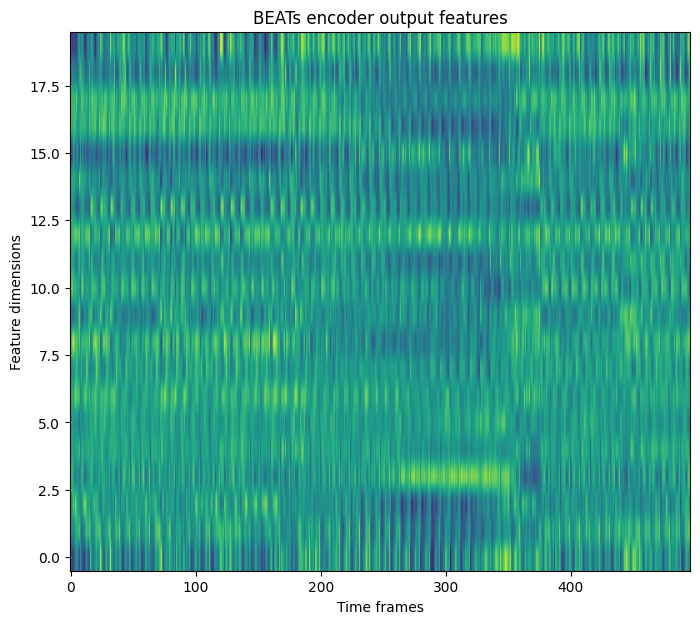

In [6]:
x_np = x.squeeze(0).cpu().numpy()
t_frames, c_dim = x_np.shape

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(x_np[:, 85:105].T, aspect='auto', origin='lower')
ax.set_xlabel('Time frames')
ax.set_ylabel('Feature dimensions')
ax.set_title('BEATs encoder output features')
plt.show()

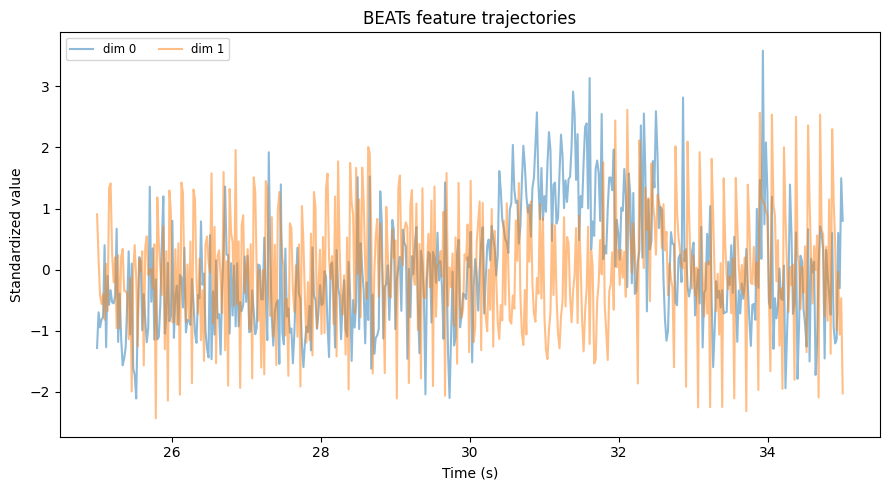

In [7]:
x_np = x.squeeze(0).cpu().numpy()      # (T_frames, C_dim)
mu = x_np.mean(axis=0, keepdims=True)  # (1, C_dim)
std = x_np.std(axis=0, keepdims=True)  # (1, C_dim)
x_std = (x_np - mu) / (std + 1e-6)     # (T_frames, C_dim)

beats_64 = x_std[:, :].T            # (64, T_frames)

T_frames, C_dim = x_std.shape
t = np.linspace(t_start, t_end, T_frames)   # same 5 s window

plt.figure(figsize=(9, 5))
for c in range(0, 2):  # First c dimensions.
    plt.plot(t, x_std[:, c], label=f"dim {c}", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Standardized value")
plt.title("BEATs feature trajectories")
plt.legend(ncol=2, fontsize="small")
plt.tight_layout()
plt.show()


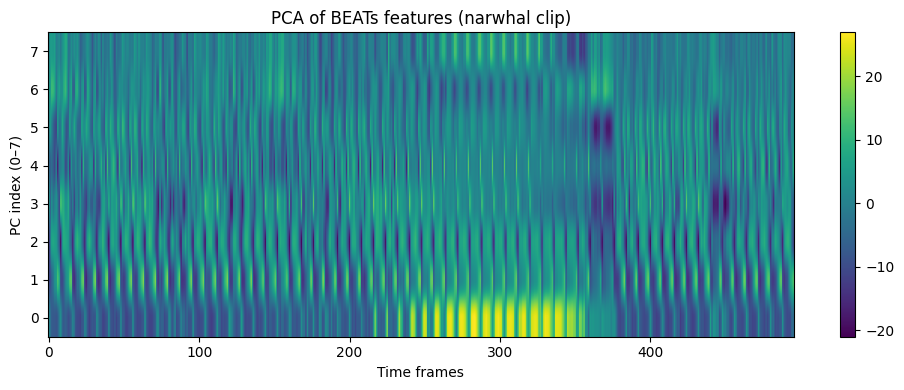

In [8]:
pca = PCA(n_components=8)
Y = pca.fit_transform(x_std)  # (T_frames, 8)

Y_img = Y.T   # (8, T_frames)

plt.figure(figsize=(10, 4))
plt.imshow(Y_img, aspect="auto", origin="lower")
plt.xlabel("Time frames")
plt.ylabel("PC index (0–7)")
plt.title("PCA of BEATs features (narwhal clip)")
plt.colorbar()
plt.tight_layout()
plt.show()


3125 3750


Text(0, 0.5, 'Mel filterbanks')

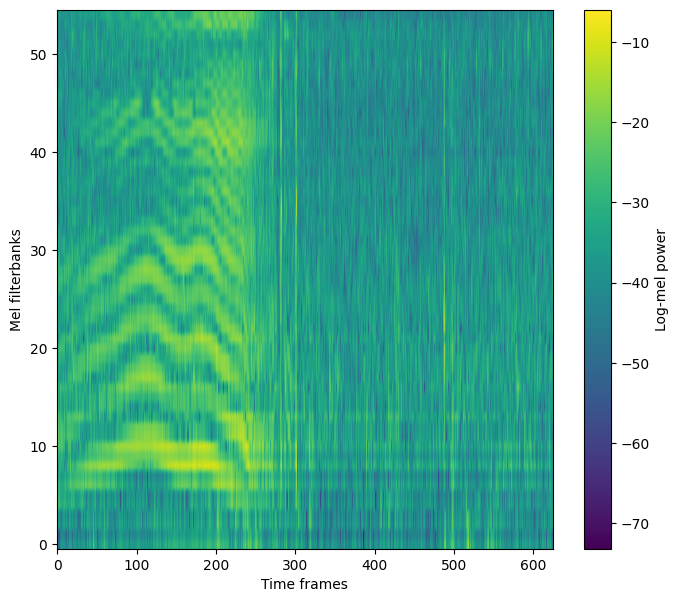

In [6]:
val1_path = r"D:\second_extraction\Tracy_6230\6230.220917120000.npz"
s1 = np.load(val1_path)["feature"]
spec = s1[0]

sr = 64000
hop_length = 512
fps = sr / hop_length
t_start = 25
t_end = t_start + 5.0
i_start = int(t_start * fps)
i_end   = int(t_end   * fps)
print(i_start, i_end)
# Good examples: 25, 65, 180, 185, 220

mels_start = 9
mels_end   = 64
seg1 = spec[mels_start:mels_end, i_start:i_end]

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(seg1, aspect='auto', origin='lower')
cbar = fig.colorbar(ax.images[0], ax=ax)
cbar.set_label('Log-mel power')
ax.set_xlabel('Time frames')
ax.set_ylabel('Mel filterbanks')

32625 33250


Text(0, 0.5, 'Mel filterbanks')

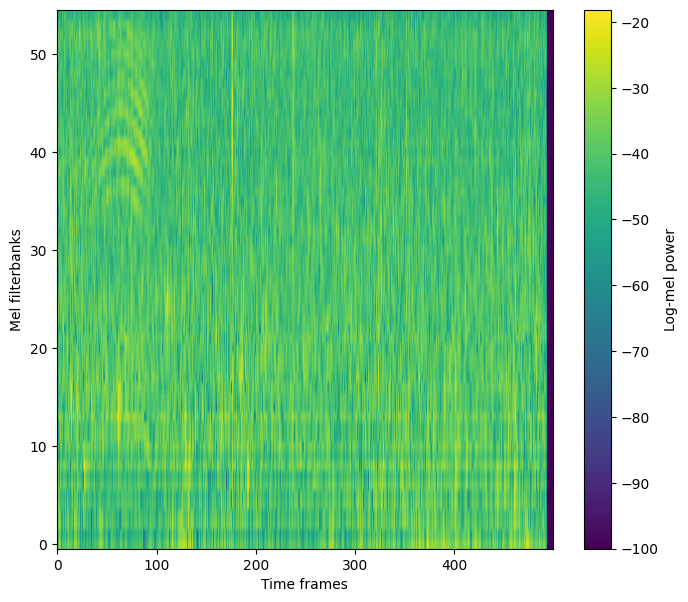

In [ ]:
val2_path = r"D:\second_extraction\Tracy_6230\6230.221003000000.npz"
s2 = np.load(val2_path)["feature"]
spec = s2[0]

t_start = 261
t_end = t_start + 5.0
i_start = int(t_start * fps)
i_end   = int(t_end * fps)
print(i_start, i_end)
# Tracy_6230\6230.221003000000.npz, t_start + 5.0, t_end = t_start + 5.0:
# Samples: 100+5, 135+5, 145+5, 160+5, 170+5,
# 190, 195+5, 205, 213, 235, 260.

mels_start = 9
mels_end   = 64
seg1 = spec[mels_start:mels_end, i_start:i_end]

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(seg1, aspect='auto', origin='lower')
cbar = fig.colorbar(ax.images[0], ax=ax)
cbar.set_label('Log-mel power')
ax.set_xlabel('Time frames')
ax.set_ylabel('Mel filterbanks')

## Experiment

In [11]:
seg_sec = 5.0
hop_sec = 2.5
seg_len = int(seg_sec * sr)
hop_len = int(hop_sec * sr)

In [12]:
def pick_random_files(val_files, dataset_root, n_random=20, seed=0, exts=(".wav")):
    val_files = [Path(p) for p in val_files]
    all_wavs = [p for p in dataset_root.rglob("*") if p.suffix in exts]
    val_set = {p.resolve() for p in val_files}
    candidates = [p for p in all_wavs if p.resolve() not in val_set]
    rng = np.random.default_rng(seed)
    random_files = rng.choice(candidates, size=min(n_random, len(candidates)), replace=False)
    files = val_files + list(random_files)
    return files

def segment_wav_mono16k(wav, sr, seg_sec=5.0, hop_sec=2.5):
    seg_len = int(seg_sec * sr)
    hop_len = int(hop_sec * sr)

    T = wav.shape[1]
    segments, seg_times = [], []
    start = 0
    while start + seg_len <= T:
        end = start + seg_len
        seg = wav[:, start:end]
        segments.append(seg.squeeze(0))
        seg_times.append((start / sr, end / sr))
        start += hop_len

    if not segments:
        return None, None
    # (N_segs, seg_len), list([start_sec, end_sec]).
    return torch.stack(segments, dim=0), seg_times 

def beats_embeddings_from_files(model, files, device, load_audio_fn
                               , seg_sec=5.0, hop_sec=5.0, batch_size=8
                               , mode="pool"):
    all_embeds = []
    all_meta = [] # (file, t0, t1, seg_idx).

    for fp in files:
        wav, sr = load_audio_fn(fp, target_sr=16000)
        segments, seg_times = segment_wav_mono16k(wav, sr, seg_sec, hop_sec)
        if segments is None:
            continue

        N_segs = segments.shape[0]
        for i in range(0, N_segs, batch_size):
            batch = segments[i:i+batch_size].to(device) # (B, T).
            x, _ = model.extract_features(batch, padding_mask=None)
            x = x.cpu()
            B, T_frames, C = x.shape

            if mode == "pool":
                clip = x.mean(dim=1)  # (B, C_dim). Collapses time dimension.
                all_embeds.append(clip)
                for j in range(B):
                    t0, t1 = seg_times[i + j]
                    all_meta.append((fp.name, t0, t1, i + j))

            elif mode == "flat_segment":
                clip = x.reshape(B, T_frames * C)  # (B, T_frames * C_dim).
                all_embeds.append(clip)
                for j in range(B):
                    t0, t1 = seg_times[i + j]
                    all_meta.append((fp.name, t0, t1, i + j))

            elif mode == "frames":
                frames = x.reshape(B * T_frames, C)  # (B * T_frames, C_dim).
                all_embeds.append(frames)
                for j in range(B):
                    seg_idx = i + j
                    t0, t1 = seg_times[seg_idx]
                    for f in range(T_frames):
                        all_meta.append((fp.name, t0, t1, seg_idx, f))

    if not all_embeds:
        return None, None
    return torch.cat(all_embeds, dim=0), all_meta # (N_total, C_dim), meta list.

In [13]:
val1_wav = Path(r"D:\data_dryad\Tracy_6230\6230.220917120000.wav")
val2_wav = Path(r"D:\data_dryad\Tracy_6230\6230.221003000000.wav")
val_files = [val2_wav]
dataset_root = Path(r"D:\data_dryad\Tracy_6230")
files = pick_random_files(val_files, dataset_root, n_random=2, seed=104, exts=(".wav"))
print(len(files), "files selected for embedding extraction.")

embeds, meta = beats_embeddings_from_files(model, files, device, load_audio, seg_sec=5.0
                                           , hop_sec=5.0, batch_size=8, mode="pool")
# hop_sec determines overlap in segments. Not equal to the hop_length of the mel-window.
print(f"Extracted {embeds.shape[0]} embeddings of dimension {embeds.shape[1]}")

3 files selected for embedding extraction.
Extracted 159 embeddings of dimension 768


### Single segment test

In [14]:
# val2_wav, sr = load_audio(r"D:\data_dryad\Tracy_6230\6230.221003000000.wav", target_sr=16000)

# segments = []
# seg_times = []
# T = val2_wav.shape[1]
# start = 0
# while start + seg_len <= T:
#     end = start + seg_len
#     seg = val2_wav[:, start:end]
#     segments.append(seg.squeeze(0))
#     seg_times.append((start / sr, end / sr))
#     start += hop_len

# segments = torch.stack(segments, dim=0)  # (N_segs, seg_len).
# print("Shape =", segments.shape)

In [15]:
# @torch.no_grad()
# def beats_clip_embeddings(model, segments, device, batch_size=8):
#     """
#     segments: (N, T_seg), mono 16k
#     returns: clip_embeds: (N, C)
#     """
#     N = segments.shape[0]
#     all_embs = []

#     for i in range(0, N, batch_size):
#         batch = segments[i:i+batch_size].to(device)  # (B, T_seg).
#         # BEATs expects (B, T).
#         x, _ = model.extract_features(
#             batch,
#             padding_mask=None,
#         )  # x: (B, T_frames, C).
#         clip_emb = x.mean(dim=1)        # (B, C) time-average.
#         all_embs.append(clip_emb.cpu())

#     return torch.cat(all_embs, dim=0)   # (N, C).

In [16]:
# clip_embeds = beats_clip_embeddings(model, segments, device, batch_size=4)
# print("clip_embeds shape:", clip_embeds.shape) # (N, C).

### $n$ files

In [17]:
emb_np = embeds.detach().numpy() # (N, C)
mu = emb_np.mean(axis=0) # (C,)
dists = np.linalg.norm(emb_np - mu, axis=1) # (N,)

# Sort segments by most unusual first.
order = np.argsort(dists)[::-1]

In [18]:
top_k = 10
print("Top candidate segments (most unusual in BEATs space):")
for rank in range(top_k):
    idx = order[rank]
    # s, e = seg_times[idx]
    file_name, s, e, seg_idx = meta[idx]
    print(f"#{rank+1:02d}: seg {idx:03d}, t = [{s:.1f}, {e:.1f}] s, dist = {dists[idx]:.3f}, file = {file_name}")


Top candidate segments (most unusual in BEATs space):
#01: seg 101, t = [240.0, 245.0] s, dist = 5.222, file = 6230.221104214000.wav
#02: seg 044, t = [220.0, 225.0] s, dist = 4.586, file = 6230.221003000000.wav
#03: seg 048, t = [240.0, 245.0] s, dist = 4.357, file = 6230.221003000000.wav
#04: seg 034, t = [170.0, 175.0] s, dist = 4.347, file = 6230.221003000000.wav
#05: seg 029, t = [145.0, 150.0] s, dist = 4.290, file = 6230.221003000000.wav
#06: seg 035, t = [175.0, 180.0] s, dist = 4.280, file = 6230.221003000000.wav
#07: seg 053, t = [0.0, 5.0] s, dist = 4.175, file = 6230.221104214000.wav
#08: seg 022, t = [110.0, 115.0] s, dist = 4.133, file = 6230.221003000000.wav
#09: seg 021, t = [105.0, 110.0] s, dist = 4.109, file = 6230.221003000000.wav
#10: seg 006, t = [30.0, 35.0] s, dist = 4.012, file = 6230.221003000000.wav


In [19]:
Z = embeds.detach().numpy() # Shape (N, C).
print("Z shape:", Z.shape)

pca = PCA(n_components=64)
Z_n = pca.fit_transform(Z) # (N, n_components).
print("PCA explained variance:", pca.explained_variance_ratio_)

# plt.figure(figsize=(8,6))
# plt.scatter(Z2[:,0], Z2[:,1], s=20, alpha=0.7)
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("PCA of BEATs segment embeddings")
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

Z shape: (159, 768)


PCA explained variance: [0.3567705  0.26966667 0.05735632 0.03733986 0.01964427 0.01820457
 0.01654713 0.01469302 0.01264518 0.01123087 0.01024689 0.00881556
 0.00826465 0.00796532 0.00716196 0.00667683 0.00589683 0.00569182
 0.00521572 0.00511796 0.00454073 0.00436046 0.00391783 0.00382377
 0.00351097 0.00333555 0.00320668 0.00307255 0.00289112 0.00257696
 0.00251047 0.00244242 0.00232845 0.00230041 0.00224704 0.00221134
 0.00206074 0.00195907 0.0019021  0.00181076 0.00177472 0.0017165
 0.00167833 0.00166037 0.00163073 0.0015636  0.00147357 0.00143133
 0.00136864 0.00135767 0.00134309 0.00126521 0.00122312 0.00120093
 0.00116538 0.00113814 0.00110262 0.00106238 0.00101533 0.00098662
 0.00096273 0.00090827 0.00087444 0.00085217]


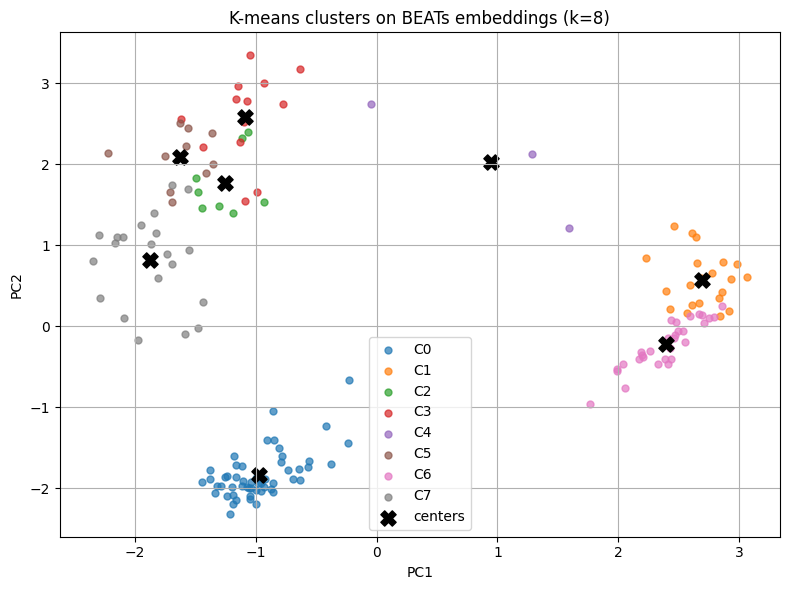

In [20]:
k = 8
kmeans = KMeans(n_clusters=k, random_state=104, n_init=20)
labels = kmeans.fit_predict(Z_n) # (N,)
centers = kmeans.cluster_centers_ # (k, C)

# PCA(2) for plotting.
pca2 = PCA(n_components=2)
Z2 = pca2.fit_transform(Z_n) # (N, 2)

plt.figure(figsize=(8,6))
for j in range(k):
    idx = (labels == j)
    plt.scatter(Z2[idx,0], Z2[idx,1], s=25, alpha=0.7, label=f"C{j}")

plt.scatter(
    pca2.transform(centers)[:,0],
    pca2.transform(centers)[:,1],
    c='black', marker='X', s=120, label='centers'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-means clusters on BEATs embeddings (k={k})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
for j in range(k):
    idx = np.where(labels == j)[0]
    print(f"\nCluster {j} has {len(idx)} segments")
    for n in idx[:10]: # Show n examples.
        print(f"  seg {n:03d}: {meta[n]}")


Cluster 0 has 53 segments
  seg 106: ('6230.221021054000.wav', 0.0, 5.0, 0)
  seg 107: ('6230.221021054000.wav', 5.0, 10.0, 1)
  seg 108: ('6230.221021054000.wav', 10.0, 15.0, 2)
  seg 109: ('6230.221021054000.wav', 15.0, 20.0, 3)
  seg 110: ('6230.221021054000.wav', 20.0, 25.0, 4)
  seg 111: ('6230.221021054000.wav', 25.0, 30.0, 5)
  seg 112: ('6230.221021054000.wav', 30.0, 35.0, 6)
  seg 113: ('6230.221021054000.wav', 35.0, 40.0, 7)
  seg 114: ('6230.221021054000.wav', 40.0, 45.0, 8)
  seg 115: ('6230.221021054000.wav', 45.0, 50.0, 9)

Cluster 1 has 21 segments
  seg 054: ('6230.221104214000.wav', 5.0, 10.0, 1)
  seg 055: ('6230.221104214000.wav', 10.0, 15.0, 2)
  seg 056: ('6230.221104214000.wav', 15.0, 20.0, 3)
  seg 057: ('6230.221104214000.wav', 20.0, 25.0, 4)
  seg 058: ('6230.221104214000.wav', 25.0, 30.0, 5)
  seg 065: ('6230.221104214000.wav', 60.0, 65.0, 12)
  seg 079: ('6230.221104214000.wav', 130.0, 135.0, 26)
  seg 080: ('6230.221104214000.wav', 135.0, 140.0, 27)
  seg 0

In [22]:
embeds_f, meta_f = beats_embeddings_from_files(model, files[0:2], device, load_audio, seg_sec=5.0
                                           , hop_sec=5.0, batch_size=8, mode="flat_segment")
# hop_sec determines overlap in segments. Not equal to the hop_length of the mel-window.
print(f"Extracted {embeds_f.shape[0]} embeddings of dimension {embeds_f.shape[1]}")

Z_flat = embeds_f.detach().numpy() # Shape (N, C).
print("Z shape:", Z_flat.shape)

Extracted 106 embeddings of dimension 190464
Z shape: (106, 190464)


In [23]:
pca = PCA(n_components=32)
Z_n_flat = pca.fit_transform(Z_flat) # (N, n_components).
print("PCA explained variance:", pca.explained_variance_ratio_)

PCA explained variance: [0.1915182  0.04651716 0.02901758 0.02615496 0.02098049 0.01901883
 0.01845301 0.01614365 0.01471471 0.01341053 0.01326283 0.01248645
 0.01196574 0.01188148 0.01102562 0.0110183  0.01060103 0.01035427
 0.01004373 0.00950334 0.00943716 0.00917635 0.00878857 0.00856169
 0.00848149 0.00842394 0.00833345 0.0081299  0.00796963 0.00782554
 0.00763651 0.00744877]


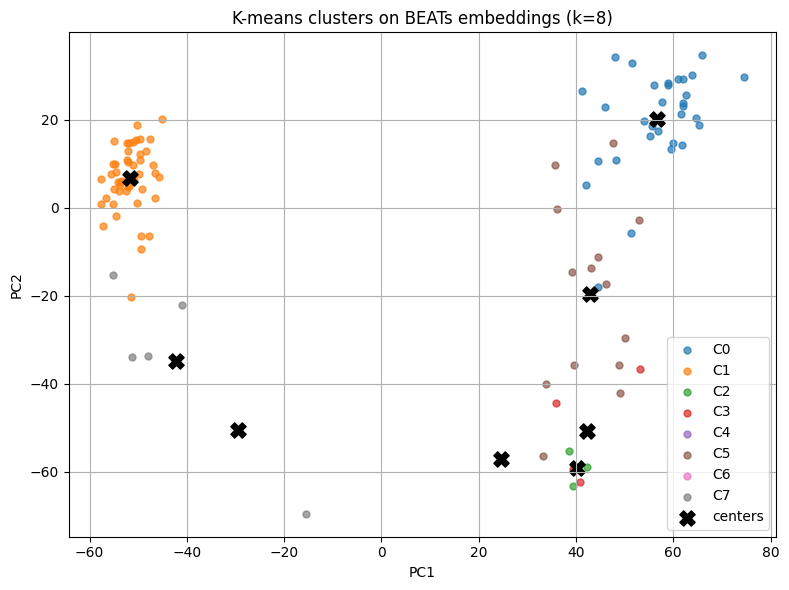

In [24]:
k = 8
kmeans = KMeans(n_clusters=k, random_state=104, n_init=20)
labels = kmeans.fit_predict(Z_n_flat) # (N,)
centers = kmeans.cluster_centers_ # (k, C)

# PCA(2) for plotting.
pca2_flat = PCA(n_components=2)
Z2_flat = pca2_flat.fit_transform(Z_n_flat) # (N, 2)

plt.figure(figsize=(8,6))
for j in range(k):
    idx = (labels == j)
    plt.scatter(Z2_flat[idx,0], Z2_flat[idx,1], s=25, alpha=0.7, label=f"C{j}")

plt.scatter(
    pca2_flat.transform(centers)[:,0],
    pca2_flat.transform(centers)[:,1],
    c='black', marker='X', s=120, label='centers'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-means clusters on BEATs embeddings (k={k})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
for j in range(k):
    idx = np.where(labels == j)[0]
    print(f"\nCluster {j} has {len(idx)} segments")
    for n in idx[:10]: # Show n examples.
        print(f"  seg {n:03d}: {meta_f[n]}")


Cluster 0 has 31 segments
  seg 000: ('6230.221003000000.wav', 0.0, 5.0, 0)
  seg 002: ('6230.221003000000.wav', 10.0, 15.0, 2)
  seg 003: ('6230.221003000000.wav', 15.0, 20.0, 3)
  seg 004: ('6230.221003000000.wav', 20.0, 25.0, 4)
  seg 005: ('6230.221003000000.wav', 25.0, 30.0, 5)
  seg 006: ('6230.221003000000.wav', 30.0, 35.0, 6)
  seg 007: ('6230.221003000000.wav', 35.0, 40.0, 7)
  seg 008: ('6230.221003000000.wav', 40.0, 45.0, 8)
  seg 009: ('6230.221003000000.wav', 45.0, 50.0, 9)
  seg 010: ('6230.221003000000.wav', 50.0, 55.0, 10)

Cluster 1 has 47 segments
  seg 055: ('6230.221104214000.wav', 10.0, 15.0, 2)
  seg 056: ('6230.221104214000.wav', 15.0, 20.0, 3)
  seg 057: ('6230.221104214000.wav', 20.0, 25.0, 4)
  seg 058: ('6230.221104214000.wav', 25.0, 30.0, 5)
  seg 059: ('6230.221104214000.wav', 30.0, 35.0, 6)
  seg 060: ('6230.221104214000.wav', 35.0, 40.0, 7)
  seg 061: ('6230.221104214000.wav', 40.0, 45.0, 8)
  seg 062: ('6230.221104214000.wav', 45.0, 50.0, 9)
  seg 063: 

## Inspect some spectrograms

3125 3750


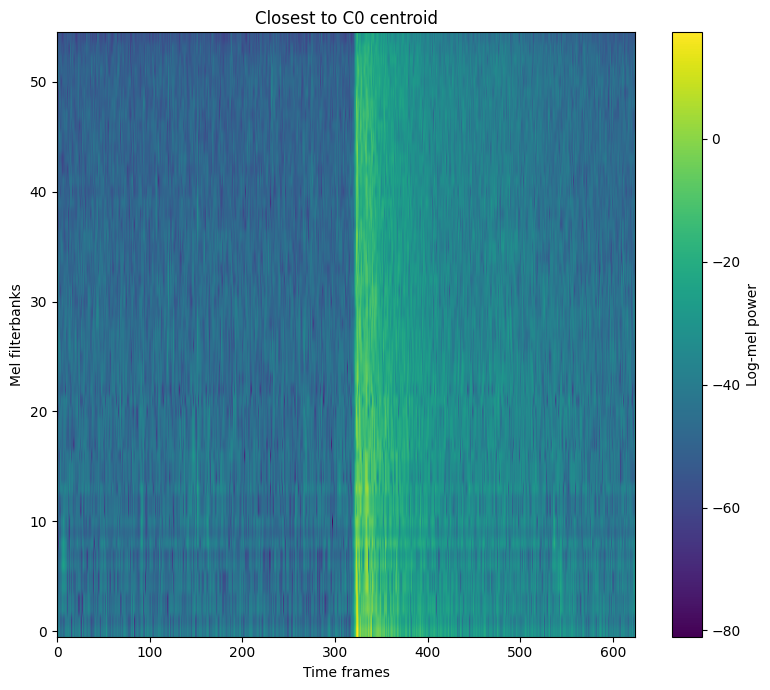

In [13]:
save_path = Path(r"C:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week15_figures")
b1_path = r"D:\second_extraction\Tracy_6230\6230.221009090000.npz"
cl = "0"
b1 = np.load(b1_path)["feature"]
spec = b1[0]

t_start = 25
t_end = t_start + 5
i_start = int(t_start * fps)
i_end   = int(t_end * fps)
print(i_start, i_end)

mels_start = 9
mels_end   = 64
seg1 = spec[mels_start:mels_end, i_start:i_end]

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(seg1, aspect='auto', origin='lower')
cbar = fig.colorbar(ax.images[0], ax=ax)
cbar.set_label('Log-mel power')
plt.title("Closest to C0 centroid")
ax.set_xlabel('Time frames')
ax.set_ylabel('Mel filterbanks')
plt.tight_layout()
plt.savefig(save_path / f"closest_C{cl}_centroid.png", dpi=300)